## PART A

### Que 1
----

Logistic Regression is a supervised learning algorithm used to predict the probability of a categorical outcome. It applies the sigmoid function to map predicted values between 0 and 1.

It is suitable for classification because it estimates class probabilities and assigns observations to classes based on a decision threshold.

### Que 2
----

Classification performance metrics evaluate how well a model predicts class labels. Common metrics include Accuracy, Precision, Recall, F1-Score, and AUC-ROC.

Accuracy alone is insufficient because it can be misleading for imbalanced datasets. For example, if 95% of cases belong to one class, a model predicting only that class achieves 95% accuracy but fails to identify the minority class.

### Que 3
-------

Type-I Error (False Positive): Predicting a risk when no actual risk exists. For example, identifying a healthy person as high-risk.

Type-II Error (False Negative): Failing to predict a risk when it actually exists. For example, classifying a high-risk patient as low-risk.

### Que 4
--------

- Precision: Proportion of predicted positive cases that are actually positive.
Precision = TP / (TP + FP)

- Recall (Sensitivity or TPR): Proportion of actual positive cases correctly identified.
Recall = TP / (TP + FN)

- F1-Score: Harmonic mean of Precision and Recall, balancing both metrics.
F1 = 2 × (Precision × Recall) / (Precision + Recall)

- TPR (True Positive Rate): Same as Recall; measures correctly identified positives.

- FPR (False Positive Rate): Proportion of actual negatives incorrectly classified as positive.
FPR = FP / (FP + TN)

### Que 5
-----

ROC (Receiver Operating Characteristic) Curve plots the True Positive Rate (TPR) against the False Positive Rate (FPR) at different threshold values.

AUC (Area Under the Curve) measures the overall ability of the classifier to distinguish between classes. A higher AUC indicates better classification performance, with 1.0 representing perfect classification and 0.5 representing random guessing.

### Que 6
------

Imbalanced data occurs when one class has significantly more samples than another. Models trained on such data tend to favor the majority class and may ignore the minority class.

As a result, the model can achieve high accuracy while performing poorly in detecting important minority-class instances, leading to biased and unreliable predictions.

## PART B

### Que 7
------

In [14]:
import pandas as pd

df = pd.read_csv("Risk_Alert_Classifier_Dataset.csv.csv")

In [15]:
print(df.columns)

Index(['customer_id', 'age', 'gender', 'region', 'employment_type',
       'annual_income_inr', 'credit_score', 'credit_utilization_ratio',
       'missed_payments_12m', 'avg_late_payment_days',
       'monthly_transaction_count', 'monthly_spend_inr',
       'cash_advance_count_6m', 'complaints_last_6m',
       'failed_login_attempts_3m', 'account_tenure_months',
       'last_transaction_date', 'debt_balance_inr', 'risk_status'],
      dtype='object')


In [16]:
X = df.drop("risk_status", axis=1)
y = df["risk_status"]

### Que 8
----

In [17]:
from sklearn.model_selection import train_test_split

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(y.value_counts(normalize=True))
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

risk_status
0    0.878913
1    0.121087
Name: proportion, dtype: float64
risk_status
0    0.878804
1    0.121196
Name: proportion, dtype: float64
risk_status
0    0.879348
1    0.120652
Name: proportion, dtype: float64


### Que 9
----

In [19]:
df.isnull().sum()

customer_id                    0
age                          140
gender                         0
region                       102
employment_type              144
annual_income_inr            166
credit_score                 216
credit_utilization_ratio     147
missed_payments_12m            0
avg_late_payment_days          0
monthly_transaction_count      0
monthly_spend_inr            129
cash_advance_count_6m          0
complaints_last_6m             0
failed_login_attempts_3m       0
account_tenure_months          0
last_transaction_date          0
debt_balance_inr               0
risk_status                    0
dtype: int64

In [36]:
from sklearn.preprocessing import LabelEncoder

le_gender = LabelEncoder()
le_region = LabelEncoder()
le_emp = LabelEncoder()

df["gender"] = le_gender.fit_transform(df["gender"])
df["region"] = le_region.fit_transform(df["region"].astype(str))
df["employment_type"] = le_emp.fit_transform(df["employment_type"].astype(str))

In [37]:
from sklearn.impute import KNNImputer

In [38]:
imputer = KNNImputer(n_neighbors=5)

In [42]:
print(X.select_dtypes(include='object').columns)

Index([], dtype='object')


In [43]:
from sklearn.impute import KNNImputer
import pandas as pd

imputer = KNNImputer(n_neighbors=5)

X_imputed = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns
)

In [44]:
X_imputed = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns
)

In [ ]:
X_imputed.isnull().sum()

customer_id                  0
age                          0
gender                       0
region                       0
employment_type              0
annual_income_inr            0
credit_score                 0
credit_utilization_ratio     0
missed_payments_12m          0
avg_late_payment_days        0
monthly_transaction_count    0
monthly_spend_inr            0
cash_advance_count_6m        0
complaints_last_6m           0
failed_login_attempts_3m     0
account_tenure_months        0
debt_balance_inr             0
dtype: int64

## PART C

### Que 10
------

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [32]:
import pandas as pd

# Target and Features
X = df.drop(['risk_status', 'last_transaction_date'], axis=1)
y = df['risk_status']

# Train Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# KNN Imputer
from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=5)

X_train_imputed = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns
)

X_test_imputed = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns
)

print("Created Successfully")
print(X_train_imputed.shape)
print(X_test_imputed.shape)

Created Successfully
(3680, 17)
(920, 17)


In [33]:
from sklearn.impute import KNNImputer
import pandas as pd

imputer = KNNImputer(n_neighbors=5)

X_train_imputed = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns
)

X_test_imputed = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns
)

In [34]:
print(X_train_imputed.isnull().sum().sum())
print(X_test_imputed.isnull().sum().sum())

0
0


In [35]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_imputed, y_train)

C:\Users\JANKI DHOLARIYA\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

### Que 11
----

In [45]:
y_pred = lr_model.predict(X_test_imputed)

Confusion Matrix

In [46]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[805   4]
 [  7 104]]


Accuracy

In [47]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy =", accuracy)

Accuracy = 0.9880434782608696


Precision, Recall, F1

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       809
           1       0.96      0.94      0.95       111

    accuracy                           0.99       920
   macro avg       0.98      0.97      0.97       920
weighted avg       0.99      0.99      0.99       920



### Que 12
-------

In [ ]:
TN, FP, FN, TP = cm.ravel()

print("Type-I Error (False Positive) =", FP)
print("Type-II Error (False Negative) =", FN)

Type-I Error (False Positive) = 4
Type-II Error (False Negative) = 7


## PART D

### Que 13
----

In [ ]:
print(df['risk_status'].value_counts())

print(df['risk_status'].value_counts(normalize=True)*100)

risk_status
0    4043
1     557
Name: count, dtype: int64
risk_status
0    87.891304
1    12.108696
Name: proportion, dtype: float64


In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_imputed, y_train)

y_pred = model.predict(X_test_imputed)
y_prob = model.predict_proba(X_test_imputed)[:,1]

C:\Users\JANKI DHOLARIYA\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       809
           1       0.96      0.94      0.95       111

    accuracy                           0.99       920
   macro avg       0.98      0.97      0.97       920
weighted avg       0.99      0.99      0.99       920



### Que 14
----------

In [53]:
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTE, ADASYN

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

Under-Sampling

In [54]:
rus = RandomUnderSampler(random_state=42)

X_under, y_under = rus.fit_resample(
    X_train_imputed,
    y_train
)

print(y_under.value_counts())

risk_status
0    446
1    446
Name: count, dtype: int64


In [55]:
model_under = LogisticRegression(max_iter=5000)

model_under.fit(X_under, y_under)

y_pred_under = model_under.predict(X_test_imputed)

print(classification_report(y_test, y_pred_under))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00       809
           1       0.95      1.00      0.97       111

    accuracy                           0.99       920
   macro avg       0.97      1.00      0.98       920
weighted avg       0.99      0.99      0.99       920



C:\Users\JANKI DHOLARIYA\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Over-Sampling

In [56]:
ros = RandomOverSampler(random_state=42)

X_over, y_over = ros.fit_resample(
    X_train_imputed,
    y_train
)

print(y_over.value_counts())

risk_status
0    3234
1    3234
Name: count, dtype: int64


In [57]:
model_over = LogisticRegression(max_iter=5000)

model_over.fit(X_over, y_over)

y_pred_over = model_over.predict(X_test_imputed)

print(classification_report(y_test, y_pred_over))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       809
           1       0.97      1.00      0.98       111

    accuracy                           1.00       920
   macro avg       0.98      1.00      0.99       920
weighted avg       1.00      1.00      1.00       920



C:\Users\JANKI DHOLARIYA\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


SMOTE

In [58]:
smote = SMOTE(random_state=42)

X_smote, y_smote = smote.fit_resample(
    X_train_imputed,
    y_train
)

print(y_smote.value_counts())

risk_status
0    3234
1    3234
Name: count, dtype: int64


In [59]:
model_smote = LogisticRegression(max_iter=5000)

model_smote.fit(X_smote, y_smote)

y_pred_smote = model_smote.predict(X_test_imputed)

print(classification_report(y_test, y_pred_smote))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       809
           1       0.98      1.00      0.99       111

    accuracy                           1.00       920
   macro avg       0.99      1.00      0.99       920
weighted avg       1.00      1.00      1.00       920



C:\Users\JANKI DHOLARIYA\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


ADASYN

In [61]:
adasyn = ADASYN(random_state=42)

X_adasyn, y_adasyn = adasyn.fit_resample(
    X_train_imputed,
    y_train
)

print(y_adasyn.value_counts())

model_adasyn = LogisticRegression(max_iter=5000)

model_adasyn.fit(X_adasyn, y_adasyn)

y_pred_adasyn = model_adasyn.predict(X_test_imputed)

print(classification_report(y_test, y_pred_adasyn))

risk_status
0    3234
1    3226
Name: count, dtype: int64
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       809
           1       0.96      1.00      0.98       111

    accuracy                           0.99       920
   macro avg       0.98      1.00      0.99       920
weighted avg       0.99      0.99      0.99       920



C:\Users\JANKI DHOLARIYA\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [62]:
print("Original")
print(y_train.value_counts())

print("\nUnder Sampling")
print(y_under.value_counts())

print("\nOver Sampling")
print(y_over.value_counts())

print("\nSMOTE")
print(y_smote.value_counts())

print("\nADASYN")
print(y_adasyn.value_counts())

Original
risk_status
0    3234
1     446
Name: count, dtype: int64

Under Sampling
risk_status
0    446
1    446
Name: count, dtype: int64

Over Sampling
risk_status
0    3234
1    3234
Name: count, dtype: int64

SMOTE
risk_status
0    3234
1    3234
Name: count, dtype: int64

ADASYN
risk_status
0    3234
1    3226
Name: count, dtype: int64


### Que 15
-----------

In [63]:
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
import pandas as pd

In [67]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=5000)

model.fit(X_train_imputed, y_train)

y_pred = model.predict(X_test_imputed)

y_prob = model.predict_proba(X_test_imputed)[:,1]

C:\Users\JANKI DHOLARIYA\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [68]:
y_prob = model.predict_proba(X_test_imputed)[:,1]

In [69]:
y_prob_over = model_over.predict_proba(X_test_imputed)[:,1]

In [70]:
y_prob_smote = model_smote.predict_proba(X_test_imputed)[:,1]

In [71]:
y_prob_adasyn = model_adasyn.predict_proba(X_test_imputed)[:,1]

In [74]:
comparison = pd.DataFrame({
    'Model': [
        'Original',
        'Under Sampling',
        'Over Sampling',
        'SMOTE',
        'ADASYN'
    ],

    'Recall': [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_under),
        recall_score(y_test, y_pred_over),
        recall_score(y_test, y_pred_smote),
        recall_score(y_test, y_pred_adasyn)
    ],

    'F1 Score': [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_under),
        f1_score(y_test, y_pred_over),
        f1_score(y_test, y_pred_smote),
        f1_score(y_test, y_pred_adasyn)
    ],

    'AUC ROC': [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, y_prob_under),
        roc_auc_score(y_test, y_prob_over),
        roc_auc_score(y_test, y_prob_smote),
        roc_auc_score(y_test, y_prob_adasyn)
    ]
})

print(comparison)

            Model    Recall  F1 Score   AUC ROC
0        Original  0.981982  0.990909  0.999978
1  Under Sampling  1.000000  0.973684  0.999009
2   Over Sampling  1.000000  0.982301  0.999978
3           SMOTE  1.000000  0.991071  0.999955
4          ADASYN  1.000000  0.977974  0.999967


In [73]:
print(
    comparison.sort_values(
        by='Recall',
        ascending=False
    )
)

            Model    Recall  F1 Score   AUC ROC
1  Under Sampling  1.000000  0.973684  0.999009
3           SMOTE  1.000000  0.991071  0.999955
2   Over Sampling  1.000000  0.982301  0.999978
4          ADASYN  1.000000  0.977974  0.999967
0        Original  0.981982  0.990909  0.999978


## PART E

### Que 16
--------

In [76]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

In [77]:
dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train_imputed, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [78]:
y_pred_dt = dt_model.predict(X_test_imputed)

In [79]:
dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy =", dt_accuracy)

Decision Tree Accuracy = 0.9695652173913043


In [80]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       809
           1       0.87      0.87      0.87       111

    accuracy                           0.97       920
   macro avg       0.93      0.93      0.93       920
weighted avg       0.97      0.97      0.97       920



### Que 17
-------

In [81]:
train_pred_dt = dt_model.predict(X_train_imputed)

train_acc_dt = accuracy_score(
    y_train,
    train_pred_dt
)

print("Training Accuracy =", train_acc_dt)

Training Accuracy = 1.0


In [82]:
test_acc_dt = accuracy_score(
    y_test,
    y_pred_dt
)

print("Testing Accuracy =", test_acc_dt)

Testing Accuracy = 0.9695652173913043


In [83]:
print("Difference =", train_acc_dt - test_acc_dt)

Difference = 0.0304347826086957


### Que 18
------

In [84]:
from sklearn.ensemble import RandomForestClassifier

In [85]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_imputed, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [86]:
y_pred_rf = rf_model.predict(X_test_imputed)

In [87]:
rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

print("Random Forest Accuracy =", rf_accuracy)

Random Forest Accuracy = 0.9956521739130435


In [88]:
print(classification_report(
    y_test,
    y_pred_rf
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       809
           1       0.99      0.97      0.98       111

    accuracy                           1.00       920
   macro avg       0.99      0.99      0.99       920
weighted avg       1.00      1.00      1.00       920



### Que 19
----------

In [89]:
rf_train_pred = rf_model.predict(
    X_train_imputed
)

rf_train_acc = accuracy_score(
    y_train,
    rf_train_pred
)

print("RF Training Accuracy =", rf_train_acc)

RF Training Accuracy = 1.0


In [90]:
rf_test_acc = accuracy_score(
    y_test,
    y_pred_rf
)

print("RF Testing Accuracy =", rf_test_acc)

RF Testing Accuracy = 0.9956521739130435


In [91]:
import pandas as pd

comparison = pd.DataFrame({
    'Model': [
        'Decision Tree',
        'Random Forest'
    ],

    'Training Accuracy': [
        train_acc_dt,
        rf_train_acc
    ],

    'Testing Accuracy': [
        test_acc_dt,
        rf_test_acc
    ]
})

print(comparison)

           Model  Training Accuracy  Testing Accuracy
0  Decision Tree                1.0          0.969565
1  Random Forest                1.0          0.995652


## PART F

### Que 20
------

#### A. Decision Tree Hyperparameter Optimization

In [92]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier

In [93]:
dt_params = {
    'max_depth': [3,5,7,10,15,None],
    'min_samples_split': [2,5,10,20],
    'min_samples_leaf': [1,2,4,8],
    'criterion': ['gini','entropy']
}

In [94]:
dt_random = RandomizedSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_distributions=dt_params,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

dt_random.fit(X_train_imputed, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'criterion': ['gini', 'entropy'], 'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... 

In [95]:
print("Best DT Parameters:")
print(dt_random.best_params_)

Best DT Parameters:
{'min_samples_split': 20, 'min_samples_leaf': 8, 'max_depth': 7, 'criterion': 'entropy'}


In [96]:
from sklearn.metrics import accuracy_score

best_dt = dt_random.best_estimator_

y_pred_dt_tuned = best_dt.predict(X_test_imputed)

dt_tuned_accuracy = accuracy_score(
    y_test,
    y_pred_dt_tuned
)

print("Tuned DT Accuracy =", dt_tuned_accuracy)

Tuned DT Accuracy = 0.9826086956521739


#### B. Random Forest Hyperparameter Optimization

In [97]:
from sklearn.ensemble import RandomForestClassifier

In [98]:
rf_params = {
    'n_estimators': [50,100,200,300],
    'max_depth': [5,10,15,20,None],
    'min_samples_split': [2,5,10],
    'min_samples_leaf': [1,2,4],
    'bootstrap': [True, False]
}

In [99]:
rf_random = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=rf_params,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

rf_random.fit(X_train_imputed, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'bootstrap': [True, False], 'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... 

In [100]:
print("Best RF Parameters:")
print(rf_random.best_params_)

Best RF Parameters:
{'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': None, 'bootstrap': False}


In [101]:
best_rf = rf_random.best_estimator_

y_pred_rf_tuned = best_rf.predict(X_test_imputed)

rf_tuned_accuracy = accuracy_score(
    y_test,
    y_pred_rf_tuned
)

print("Tuned RF Accuracy =", rf_tuned_accuracy)

Tuned RF Accuracy = 0.9967391304347826


### Que 21
--------

In [102]:
from sklearn.model_selection import GridSearchCV

In [103]:
grid_params = {
    'n_estimators': [100,150,200],
    'max_depth': [10,15,20],
    'min_samples_split': [2,5],
    'min_samples_leaf': [1,2]
}

In [104]:
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=grid_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train_imputed, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 15, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 150, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and paramete

In [105]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}


In [106]:
best_grid_model = grid_search.best_estimator_

y_pred_grid = best_grid_model.predict(
    X_test_imputed
)

grid_accuracy = accuracy_score(
    y_test,
    y_pred_grid
)

print("Grid Search Accuracy =", grid_accuracy)

Grid Search Accuracy = 0.9978260869565218


### Que 22
----------

In [107]:
import pandas as pd

comparison = pd.DataFrame({

    'Model': [
        'Decision Tree Untuned',
        'Decision Tree Tuned',
        'Random Forest Untuned',
        'Random Forest Tuned',
        'Grid Search RF'
    ],

    'Accuracy': [
        dt_accuracy,
        dt_tuned_accuracy,
        rf_accuracy,
        rf_tuned_accuracy,
        grid_accuracy
    ]
})

print(comparison)

                   Model  Accuracy
0  Decision Tree Untuned  0.969565
1    Decision Tree Tuned  0.982609
2  Random Forest Untuned  0.995652
3    Random Forest Tuned  0.996739
4         Grid Search RF  0.997826


## PART G

### Que 23
---------

In [108]:
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

import matplotlib.pyplot as plt

In [109]:
y_prob_lr = model.predict_proba(X_test_imputed)[:,1]

y_prob_under = model_under.predict_proba(X_test_imputed)[:,1]

y_prob_over = model_over.predict_proba(X_test_imputed)[:,1]

y_prob_smote = model_smote.predict_proba(X_test_imputed)[:,1]

y_prob_adasyn = model_adasyn.predict_proba(X_test_imputed)[:,1]

y_prob_rf = rf_model.predict_proba(X_test_imputed)[:,1]

y_prob_grid = best_grid_model.predict_proba(X_test_imputed)[:,1]

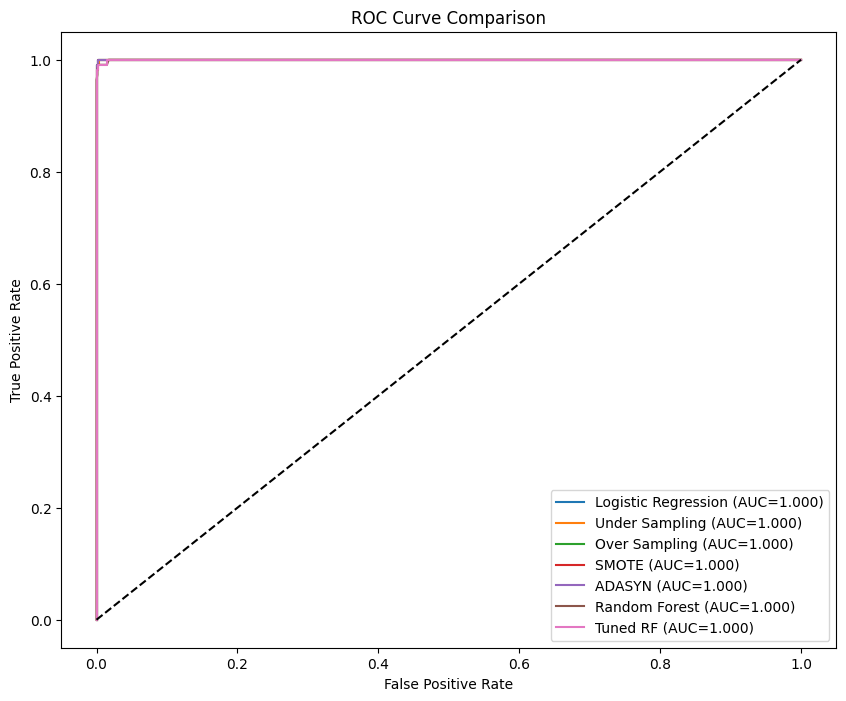

In [110]:
plt.figure(figsize=(10,8))

models = {
    "Logistic Regression": y_prob_lr,
    "Under Sampling": y_prob_under,
    "Over Sampling": y_prob_over,
    "SMOTE": y_prob_smote,
    "ADASYN": y_prob_adasyn,
    "Random Forest": y_prob_rf,
    "Tuned RF": y_prob_grid
}

for name, probs in models.items():

    fpr, tpr, _ = roc_curve(y_test, probs)

    auc = roc_auc_score(y_test, probs)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={auc:.3f})"
    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

### Que 24
--------

In [111]:
import pandas as pd

auc_table = pd.DataFrame({

    'Model':[
        'Logistic Regression',
        'Under Sampling',
        'Over Sampling',
        'SMOTE',
        'ADASYN',
        'Random Forest',
        'Tuned Random Forest'
    ],

    'AUC ROC':[
        roc_auc_score(y_test,y_prob_lr),
        roc_auc_score(y_test,y_prob_under),
        roc_auc_score(y_test,y_prob_over),
        roc_auc_score(y_test,y_prob_smote),
        roc_auc_score(y_test,y_prob_adasyn),
        roc_auc_score(y_test,y_prob_rf),
        roc_auc_score(y_test,y_prob_grid)
    ]
})

print(auc_table)

                 Model   AUC ROC
0  Logistic Regression  0.999978
1       Under Sampling  0.999944
2        Over Sampling  0.999978
3                SMOTE  0.999955
4               ADASYN  0.999967
5        Random Forest  0.999822
6  Tuned Random Forest  0.999844


In [112]:
auc_table.sort_values(
    by='AUC ROC',
    ascending=False
)

,Model,AUC ROC
0,Logistic Regression,0.999978
2,Over Sampling,0.999978
4,ADASYN,0.999967
3,SMOTE,0.999955
1,Under Sampling,0.999944
6,Tuned Random Forest,0.999844
5,Random Forest,0.999822


### Que 25
-------

In [113]:
from sklearn.metrics import recall_score

recall_table = pd.DataFrame({

    'Model':[
        'Logistic Regression',
        'Under Sampling',
        'Over Sampling',
        'SMOTE',
        'ADASYN',
        'Random Forest',
        'Tuned RF'
    ],

    'Recall':[
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_under),
        recall_score(y_test, y_pred_over),
        recall_score(y_test, y_pred_smote),
        recall_score(y_test, y_pred_adasyn),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_grid)
    ]
})

print(recall_table.sort_values(
    by='Recall',
    ascending=False
))

                 Model    Recall
1       Under Sampling  1.000000
2        Over Sampling  1.000000
3                SMOTE  1.000000
4               ADASYN  1.000000
0  Logistic Regression  0.981982
6             Tuned RF  0.981982
5        Random Forest  0.972973


## PART H

In [ ]:
!pip install ydata_profiling
import pandas as pd
from ydata_profiling import ProfileReport

# ─── Data Load ───
df = pd.read_csv('Risk_Alert_Classifier_Dataset.csv.csv')

# ─── Poora EDA report ek line mein! ───
profile = ProfileReport(
    df,
    title="Risk Alert Classifier Dataset — Full EDA Report",
    explorative=True      # Extra deep analysis
)

# ─── HTML file mein save karo ───
profile.to_file("Risk_Alert_Classifier_Dataset.html")
print("Report saved! Browser mein kholo.")

# ─── Jupyter Notebook mein directly dikhao ───
profile.to_notebook_iframe()

# ─── Minimal report (bade datasets ke liye faster) ───
profile_minimal = ProfileReport(df, minimal=True)
profile_minimal.to_file("quick_report.html")